In [1]:
# Load the CIFAR-10 dataset
import torch
import torchvision.datasets as datasets
import torchvision.transforms as transforms
# Show 10 images from the training set with their labels
import matplotlib.pyplot as plt
import numpy as np
# Load a pre-trained MobileNetV3 and inspect its structure
import torchvision.models as models
import torch.nn.functional as F
import torchvision.models as models
from torch import nn as nn

In [2]:
from google.colab import drive
drive.mount('/content/drive')

SAVE_LOCATION = '/content/drive/MyDrive/epita/action-learning/model/'

Mounted at /content/drive


In [3]:
def load_data(batch_size, data_dir="data"):
    """Load the FCIFAR-10 dataset."""
    # Define transforms to normalize the data
    transform = transforms.Compose(
        [transforms.ToTensor(), transforms.Normalize((0.5,), (0.5,))]
    )
    # Download and load the training data
    trainset = datasets.CIFAR10(
        data_dir, download=True, train=True, transform=transform
    )
    trainloader = torch.utils.data.DataLoader(
        trainset, batch_size=batch_size, shuffle=True
    )
    # Download and load the test data
    testset = datasets.CIFAR10(
        data_dir, download=True, train=False, transform=transform
    )
    testloader = torch.utils.data.DataLoader(
        testset, batch_size=batch_size, shuffle=True
    )

    return trainloader, testloader

# Define some helper functions to helps with the labels
def get_class_names():
    """Return the list of classes in the Fashion-MNIST dataset."""
    return [
        'airplane',
        'automobile',
        'bird',
        'cat',
        'deer',
        'dog',
        'frog',
        'horse',
        'ship',
        'truck'
    ]


def get_class_name(class_index):
    """Return the class name for the given index."""
    return get_class_names()[class_index]


def get_class_index(class_name):
    """Return the class index for the given name."""
    return get_class_names().index(class_name)


for class_index in range(10):
    print(f"class_index={class_index}, class_name={get_class_name(class_index)}")

class_index=0, class_name=airplane
class_index=1, class_name=automobile
class_index=2, class_name=bird
class_index=3, class_name=cat
class_index=4, class_name=deer
class_index=5, class_name=dog
class_index=6, class_name=frog
class_index=7, class_name=horse
class_index=8, class_name=ship
class_index=9, class_name=truck


In [4]:
# Define a custom lighting layer
class LightingLayer(nn.Module):
    def __init__(self, brightness_factor=1.0, contrast_factor=1.0):
        super(LightingLayer, self).__init__()
        self.brightness_factor = brightness_factor
        self.contrast_factor = contrast_factor

    def forward(self, image):
        # Adjust brightness
        image = transforms.functional.adjust_brightness(image, self.brightness_factor)
        # Adjust contrast
        image = transforms.functional.adjust_contrast(image, self.contrast_factor)
        return image

In [5]:
# Define a model class that extends the nn.Module class
class MobileNetV3(nn.Module):
    def __init__(self):
        super(MobileNetV3, self).__init__()
        # Load the pre-trained MobileNetV3 (Small) architecture
        self.model = models.mobilenet_v3_small(pretrained=True)
        # Replace the last fully-connected layer with a new one of the right size
        self.model.classifier[3] = nn.Linear(1024, 10)
        # Freeze all the weights of the network except for the last fully-connected layer
        self.freeze()

    def forward(self, x):
        # Resize the input to 224x224, since MobileNetV3 (Small) expects images of that size
        if x.shape[2:] != (224, 224):
            x = F.interpolate(x, size=(224, 224), mode="bilinear", align_corners=False)

        # Forward pass
        return self.model(x)

    def freeze(self):
        # Freeze all the weights of the network except for the last fully-connected layer
        for param in self.model.parameters():
            param.requires_grad = False

        # Unfreeze the final layer
        for param in self.model.classifier[3].parameters():
            param.requires_grad = True

    def unfreeze(self):
        # Unfreeze all the weights of the network
        for param in self.model.parameters():
            param.requires_grad = True

    def quantization(self):
        # Quantize the model
        # Set quantization backend
        torch.backends.quantized.engine = 'qnnpack'
        self.model.eval()
        self.model.qconfig = torch.quantization.get_default_qconfig('fbgemm')

        # Apply dynamic quantization
        quantized_model = torch.quantization.quantize_dynamic(
            self.model, {nn.Linear, nn.Conv2d}, dtype=torch.qint8
        )
        return quantized_model

In [6]:
# Set the device as GPU, MPS, or CPU according to availability
force_cpu = torch.device("cpu")
if torch.cuda.is_available():
    device = torch.device("cuda")
elif torch.backends.mps.is_available():
    device = torch.device("mps")
else:
    device = torch.device("cpu")

print(f"Using device: {device}")

Using device: cpu


In [7]:
# Define the lighting layer
lighting_layer = LightingLayer(brightness_factor=0.8, contrast_factor=1.2)

In [9]:
"""
PATH = '/'.join([SAVE_LOCATION, 'mobilenet_transfer_v1.pth'])
model_temp = MobileNetV3()

model_temp.load_state_dict(torch.load(PATH, weights_only=True))
model_temp = model_temp.quantization()
"""

"\nPATH = '/'.join([SAVE_LOCATION, 'mobilenet_transfer_v1.pth'])\nmodel_temp = MobileNetV3()\n\nmodel_temp.load_state_dict(torch.load(PATH, weights_only=True))\nmodel_temp = model_temp.quantization()\n"

In [10]:
# Load train, test
trainloader, testloader = load_data(64)
# Load a trained model
model = torch.load('/'.join([SAVE_LOCATION, 'mobilenet_transfer_v1_2.pth']), weights_only=False)
model.eval()

# Move the model to the configured device
model.cpu()

/usr/local/lib/python3.11/dist-packages/torch/_utils.py:410: UserWarning: TypedStorage is deprecated. It will be removed in the future and UntypedStorage will be the only storage class. This should only matter to you if you are using storages directly.  To access UntypedStorage directly, use tensor.untyped_storage() instead of tensor.storage()
  device=storage.device,


MobileNetV3(
  (features): Sequential(
    (0): Conv2dNormActivation(
      (0): Conv2d(3, 16, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
      (1): BatchNorm2d(16, eps=0.001, momentum=0.01, affine=True, track_running_stats=True)
      (2): Hardswish()
    )
    (1): InvertedResidual(
      (block): Sequential(
        (0): Conv2dNormActivation(
          (0): Conv2d(16, 16, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), groups=16, bias=False)
          (1): BatchNorm2d(16, eps=0.001, momentum=0.01, affine=True, track_running_stats=True)
          (2): ReLU(inplace=True)
        )
        (1): SqueezeExcitation(
          (avgpool): AdaptiveAvgPool2d(output_size=1)
          (fc1): Conv2d(16, 8, kernel_size=(1, 1), stride=(1, 1))
          (fc2): Conv2d(8, 16, kernel_size=(1, 1), stride=(1, 1))
          (activation): ReLU()
          (scale_activation): Hardsigmoid()
        )
        (2): Conv2dNormActivation(
          (0): Conv2d(16, 16, kernel_size=(1, 1), 

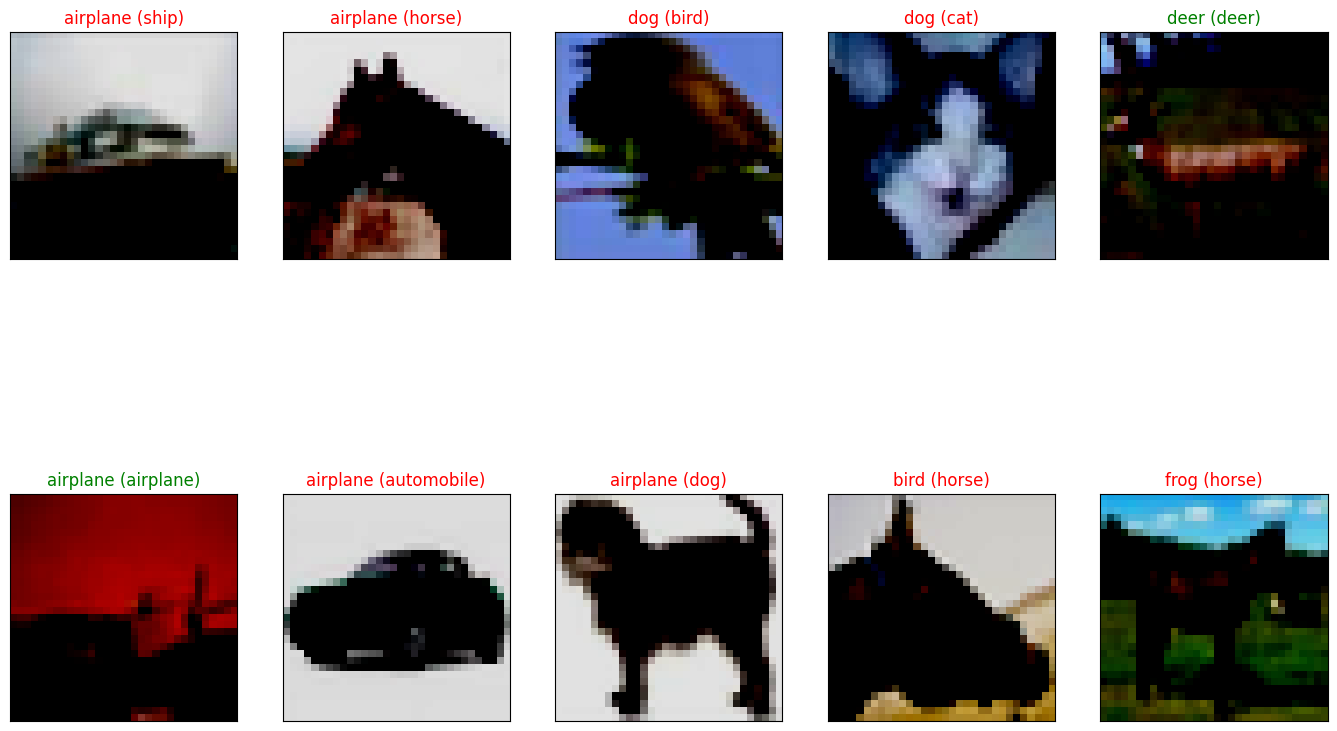

In [11]:
# Get the first batch of images and labels
images, labels = next(iter(testloader))

# Move tensors to the configured device
images = images.to(force_cpu)
labels = labels.to(force_cpu)

# Forward pass
images = lighting_layer(images)
outputs = model(images)
_, predicted = torch.max(outputs.data, 1)

# Plot the images with labels, at most 10
fig = plt.figure(figsize=(17,11))

for idx in np.arange(min(10, len(images))):
    ax = fig.add_subplot(2, 10 // 2, idx + 1, xticks=[], yticks=[])
    ax.imshow(np.transpose(np.squeeze(images.cpu()[idx]), (1, 2, 0)))
    ax.set_title(
        "{} ({})".format(get_class_name(predicted[idx]), get_class_name(labels[idx])),
        color=("green" if predicted[idx] == labels[idx] else "red"),
    )

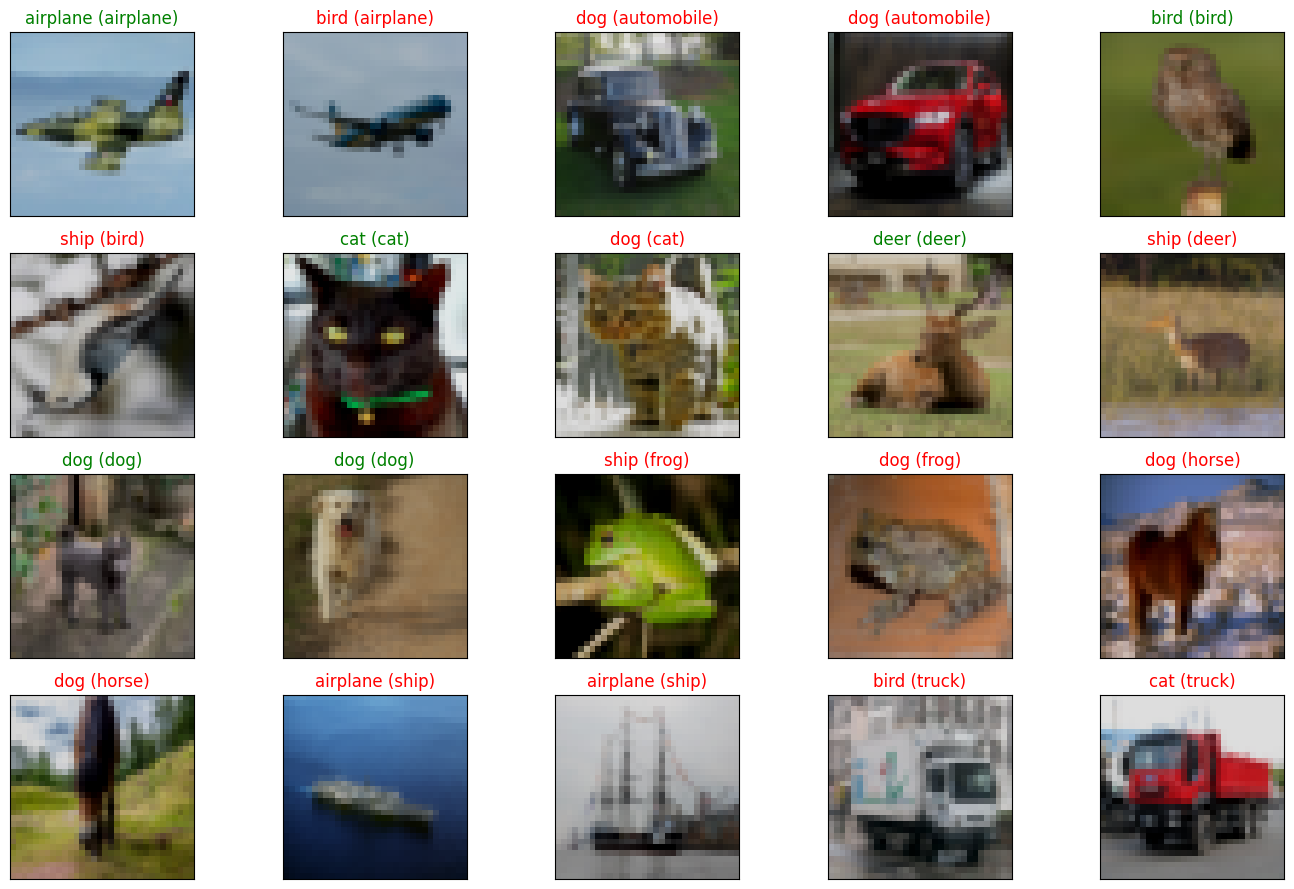

In [12]:
import torchvision.transforms as transforms
from torchvision.datasets import ImageFolder
from torch.utils.data import DataLoader


OUTSIDE_PICT = '/content/drive/MyDrive/epita/action-learning/test_pic/'

# Define transform to match CIFAR-10 preprocessing
transform = transforms.Compose([
    transforms.Resize((32, 32)),  # Resize images to match CIFAR-10 input size
    transforms.ToTensor(),
    #transforms.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5])  # Normalize similar to CIFAR-10
])


dataset = ImageFolder(root=OUTSIDE_PICT, transform=transform)
outsidetest = DataLoader(dataset, batch_size=20, shuffle=False)

# Get first batch of images
images, labels = next(iter(outsidetest))

# Move tensors to the configured device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
images = images.to(force_cpu)
labels = labels.to(force_cpu)

# Forward pass
images = lighting_layer(images)
outputs = model(images)
_, predicted = torch.max(outputs.data, 1)

# Plot the images with labels
fig = plt.figure(figsize=(17, 11))

for idx in range(len(images)):
    ax = fig.add_subplot(4, 5, idx + 1, xticks=[], yticks=[])
    ax.imshow(np.transpose(images.cpu()[idx].numpy(), (1, 2, 0)))  # Convert tensor to image
    ax.set_title(
        "{} ({})".format(get_class_name(predicted[idx]), get_class_name(labels[idx])),
        color=("green" if predicted[idx] == labels[idx] else "red"),
    )

plt.show()


In [13]:
import os
# Function to print model size
def model_size(model, label=""):
    torch.save(model.state_dict(), "temp.p")
    size = os.path.getsize("temp.p")
    print("Model:", label, '\t', 'Size (KB):', size/1e3)
    os.remove('temp.p')
    return size

# Compare model sizes
f_size = model_size(model, "int8")
print(f_size)

Model: int8 	 Size (KB): 4432.91
4432910
